# Evaluation-Driven Development with Amazon SageMaker AI MLflow Apps

📖 **Read the companion blog post:** [Evaluation-Driven Development with Amazon SageMaker AI MLflow Apps](https://aws.amazon.com/blogs/machine-learning/evaluation-driven-development-with-amazon-sagemaker-ai-mlflow-apps)

> **Note:** This notebook is sample code provided for demonstration and learning. It is not production-ready and should not be deployed to a production environment without additional review and security testing, including hardening the IAM policies, S3 bucket configuration, and credential handling for your own environment.

## Introduction

This notebook demonstrates **Evaluation-Driven Development (EDD)**: treating evaluation as an operational part of building an LLM application rather than an after-the-fact report. Because LLM outputs are non-deterministic and quality is multi-dimensional, "the model feels worse today" is not a metric. EDD makes quality measurable — define criteria explicitly, score every change against the same dataset, and let production failures feed back into the dataset so the suite hardens over time.

You'll build a conversational RAG chatbot that answers Amazon Bedrock questions — retrieving from a knowledge base and calling a `get_pricing` tool — and evaluate it end to end across four dimensions: response quality, retrieval, tool use, and whole-session behavior. The same evaluation pass runs offline to gate changes before deployment and online against production traces.

Everything runs on AWS: **MLflow 3.10.1 on Amazon SageMaker AI MLflow Apps** provides tracking, versioned datasets, scorers, and the trace UI; **Amazon Bedrock** serves the generator models and the LLM-as-judge; and an **Amazon Bedrock Knowledge Base** backed by **Amazon S3 Vectors** powers retrieval.

## What this notebook covers

1. **Setup** — connect to a SageMaker AI MLflow App, enable Amazon Bedrock auto-tracing.
2. **KB provisioning** (idempotent) — an Amazon Bedrock Knowledge Base backed by Amazon S3 Vectors. First run provisions everything; subsequent runs skip in seconds.
3. **Demo app** — a RAG-backed Bedrock-docs chatbot with one tool (`get_pricing`), traced end to end.
4. **Phase 2 (Dataset)** — create an MLflow GenAI dataset with response-quality, RAG, and tool-use records.
5. **Phase 3 (Iterate)** — built-in scorers, deterministic `@scorer` functions, custom `make_judge()` LLM judges, judge validation against human labels, triangulation, session-level teaser.
6. **Phase 4 (Monitor)** — programmatic scheduled scorers, cost + quality readout (cost comes for free from `mlflow.bedrock.autolog()`).
7. **Phase 5 (Close the loop)** — sample failing traces back into the dataset.
8. **Summary + clean up** — flat readout, then a final cell that deletes all provisioned resources.

## Architecture

The demo agent runs on Amazon Bedrock using the gpt-oss-120b foundation model, retrieves from an Amazon Bedrock Knowledge Base (Amazon Titan Embeddings v2 on Amazon S3 Vectors), and emits traces to managed MLflow on Amazon SageMaker AI MLflow Apps. `mlflow.genai.evaluate` invokes a different model family — the Claude Sonnet 4.6 foundation model on Amazon Bedrock — as the LLM-as-judge to avoid self-preference bias.

<img alt="EDD architecture: a conversational agent on Amazon Bedrock (gpt-oss-120b) with an Amazon Bedrock Knowledge Base on Amazon S3 Vectors, emitting traces to managed MLflow on Amazon SageMaker AI, with a Claude Sonnet 4.6 LLM-as-judge." src="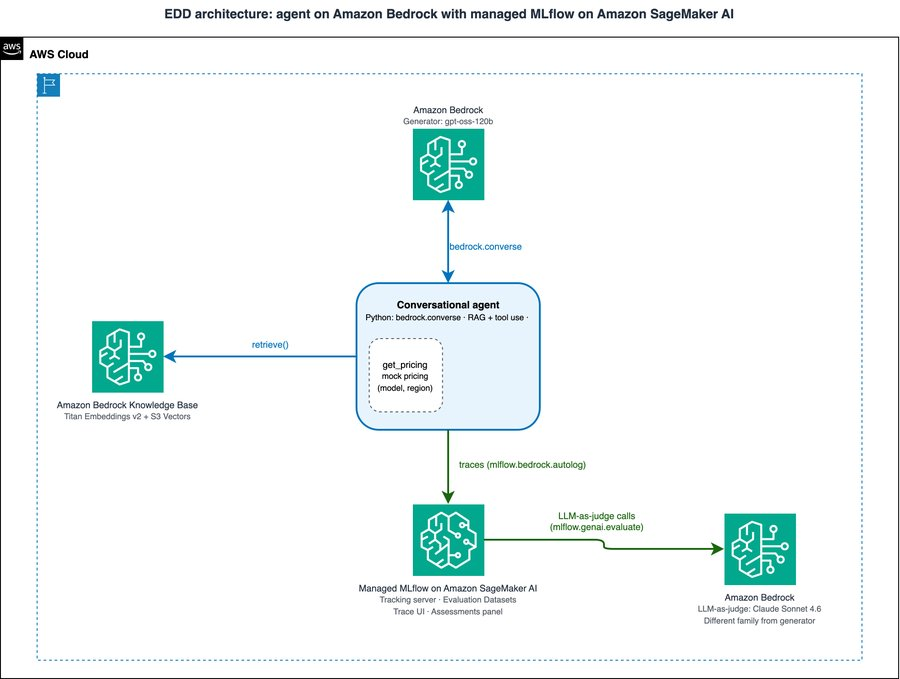" width="760">

## Prerequisites

Before running this notebook, make sure the following are in place:

- **An AWS account** with permissions for Amazon Bedrock, Amazon S3 (including S3 Vectors), AWS IAM (to create a Knowledge Base execution role), and Amazon SageMaker AI.
- **An Amazon SageMaker AI MLflow App.** Provision one from the [Amazon SageMaker AI MLflow Apps setup guide](https://docs.aws.amazon.com/sagemaker/latest/dg/mlflow.html) and copy its ARN into the Configuration cell below.
- **Amazon Bedrock model access** in your Region for the generator models (`openai.gpt-oss-120b`, `openai.gpt-oss-20b`), the Claude Sonnet 4.6 judge, and Amazon Titan Text Embeddings V2.
- **Python 3.10 or later**, with AWS credentials configured in the environment (an Amazon SageMaker Studio notebook, or local Jupyter with credentials set up). Dependencies are installed in the next cell.

**Cost:** This notebook creates billable resources — an Amazon S3 source bucket, Amazon S3 Vectors storage, an Amazon Bedrock Knowledge Base, and an IAM role — and makes Amazon Bedrock API and embedding calls (charged per token). Run the **Clean up** section at the end when finished to stop ongoing storage charges.

## 1. Install dependencies

In [ ]:
%pip install --quiet "mlflow>=3.10.1,<3.11" boto3 "sagemaker-mlflow>=0.3.0" pandas litellm tenacity

## 2. Configuration

Replace `TRACKING_URI` with your own MLflow App ARN. `REGION` is pinned to `us-east-1` for Amazon S3 Vectors availability.

In [ ]:
import os

# --- Configuration --------------------------------------------------------
# Set TRACKING_URI to your Amazon SageMaker AI MLflow App ARN (or the MLFLOW_TRACKING_URI
# environment variable). Everything else -- Region, account ID, bucket names --
# is derived from it, so this is the only value you need to provide.
TRACKING_URI = os.environ.get(
    "MLFLOW_TRACKING_URI",
    "arn:aws:sagemaker:us-east-1:123456789012:mlflow-app/app-ABCDEFGH",
)
if "123456789012" in TRACKING_URI or "app-ABCDEFGH" in TRACKING_URI:
    raise ValueError(
        "Set MLFLOW_TRACKING_URI (or edit TRACKING_URI above) to your SageMaker AI "
        "MLflow App ARN before running, e.g. "
        "arn:aws:sagemaker:us-east-1:123456789012:mlflow-app/app-ABCDEFGH."
    )

# Region and account come straight from the ARN
# (arn:aws:sagemaker:<region>:<account>:mlflow-app/...), so the Knowledge Base,
# buckets, and IAM role all land in the same account as the MLflow App.
_arn = TRACKING_URI.split(":")
REGION = _arn[3]
ACCOUNT_ID = _arn[4]

BEDROCK_MODEL_ID = "openai.gpt-oss-120b-1:0"

# Judge -- a different model family from both gpt-oss agents, to avoid self-preference bias.
JUDGE_BEDROCK_MODEL_ID = "global.anthropic.claude-sonnet-4-6"
JUDGE_MODEL = f"bedrock:/{JUDGE_BEDROCK_MODEL_ID}"

EMBEDDING_MODEL_ARN = f"arn:aws:bedrock:{REGION}::foundation-model/amazon.titan-embed-text-v2:0"

EXPERIMENT_NAME = "edd-agenteval-gptoss"

# KB resources (idempotent, check-or-create). Bucket names derive from ACCOUNT_ID
KB_NAME = "edd-blog-kb"
CORPUS_BUCKET = f"edd-blog-corpus-{ACCOUNT_ID}"
VECTOR_BUCKET = f"edd-blog-vectors-{ACCOUNT_ID}"
VECTOR_INDEX = "edd-blog-index"

print(f"Region:    {REGION}")
print(f"Tracking:  {TRACKING_URI}")
print(f"Experiment:{EXPERIMENT_NAME}")
print(f"Generator: {BEDROCK_MODEL_ID}")
print(f"Judge:     {JUDGE_BEDROCK_MODEL_ID}  (different family from both agents -- avoids self-preference bias)")
print(f"Embedding: amazon.titan-embed-text-v2:0")

## 3. Connect to MLflow and enable Amazon Bedrock auto-tracing

In [ ]:
import boto3
import mlflow
from botocore.config import Config

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)
mlflow.bedrock.autolog()

# Bound the read timeout and retry on transient failures. LLM-as-judge passes fire
# many concurrent Bedrock calls; without a read timeout, a half-open connection can
# leave a worker blocked indefinitely and the evaluate() cell appears to hang.
BEDROCK_CFG = Config(read_timeout=120, connect_timeout=10,
                     retries={"max_attempts": 4, "mode": "adaptive"})

bedrock = boto3.client("bedrock-runtime", region_name=REGION, config=BEDROCK_CFG)
bedrock_agent = boto3.client("bedrock-agent", region_name=REGION, config=BEDROCK_CFG)
bedrock_agent_rt = boto3.client("bedrock-agent-runtime", region_name=REGION, config=BEDROCK_CFG)
s3 = boto3.client("s3", region_name=REGION, config=BEDROCK_CFG)
s3_vectors = boto3.client("s3vectors", region_name=REGION, config=BEDROCK_CFG)
iam = boto3.client("iam", config=BEDROCK_CFG)

print("Bedrock autolog: ENABLED")

## 4. Region for the LLM judges

MLflow's LLM judges (`Correctness`, `make_judge()`, etc.) use LiteLLM internally to standardize across model providers (`openai:/`, `anthropic:/`, `bedrock:/`, ...). For `bedrock:/` judges, LiteLLM resolves AWS credentials from the boto3 default credential chain -- the same credentials the rest of the notebook uses -- so no access keys are placed in code or environment variables. We set only the AWS Region so the judges call the correct Amazon Bedrock endpoint.

In [ ]:
# MLflow's LLM judges route Amazon Bedrock calls through LiteLLM, which resolves AWS
# credentials from the boto3 default credential chain -- the same credentials the
# rest of this notebook uses -- so no access keys are placed in code or env vars.
# Only the Region is set, so judges call the correct Amazon Bedrock endpoint.
os.environ["AWS_REGION"] = REGION
os.environ["AWS_DEFAULT_REGION"] = REGION
print(f"Region set for LLM judges: {REGION}")

## 5. Source bucket + corpus upload

15 short, illustrative Amazon Bedrock excerpts live inline in this cell (in the companion repo they'd be `corpus/*.md`). They are mock teaching content, not authoritative AWS documentation — figures such as prices and quotas are deliberately generalized, so always confirm current details in the official AWS docs. Idempotent and **content-aware**: each doc's MD5 is compared against the stored object's ETag, so edits to a doc's contents (not only new filenames) are detected and re-uploaded. When anything changes, the ingestion cell below starts a fresh job so the KB doesn't serve stale vectors.

> **Note:** This section creates billable resources (S3 source bucket, S3 Vectors storage, Amazon Bedrock Knowledge Base, IAM role). Charges accrue for storage and Amazon Bedrock API/embedding calls until you run the **Clean up** section.


In [ ]:
from botocore.exceptions import ClientError

CORPUS = {
    "claude-sonnet-4-6.md": """# Claude Sonnet 4.6 on Amazon Bedrock\n\nClaude Sonnet 4.6 is Anthropic's latest Sonnet generation model available on Amazon Bedrock. It supports a 1,000,000-token context window and is optimized for high-quality responses with strong reasoning and tool use. Sonnet 4.6 is accessed through cross-region inference profiles whose prefix matches the caller's geography: `us.anthropic.claude-sonnet-4-6` in the Americas (us-east-1, us-west-2), `eu.anthropic.claude-sonnet-4-6` in Europe (eu-west-1, eu-central-1), and `jp.anthropic.claude-sonnet-4-6` in Japan (ap-northeast-1). Use the profile that matches your Region. Sonnet 4.6 is recommended for production workloads that need balanced quality and cost.""",
    "claude-haiku-4-5.md": """# Claude Haiku 4.5 on Amazon Bedrock\n\nClaude Haiku 4.5 is Anthropic's low-latency, cost-efficient model on Amazon Bedrock. The Bedrock model ID is `anthropic.claude-haiku-4-5-20251001-v1:0`. Use Haiku 4.5 for high-throughput workloads, RAG responses, classification, and latency-sensitive applications. Context window is 200,000 tokens.""",
    "bedrock-converse-api.md": """# The Bedrock Converse API\n\nThe `converse` API is the recommended way to call chat models on Amazon Bedrock. It provides a standardized interface across all chat-capable foundation models (Claude, Nova, Llama, etc.), supports tool use, streaming, and automatically captures rich traces when `mlflow.bedrock.autolog()` is enabled. Use `converse` for multi-turn chat and `converse_stream` for streamed responses.""",
    "bedrock-regions.md": """# Amazon Bedrock Regions\n\nAmazon Bedrock is available in multiple AWS Regions including us-east-1, us-west-2, eu-west-1, ap-northeast-1, and others. Model availability varies by region. Cross-region inference profiles (prefixed with `us.`, `eu.`, `jp.`) automatically route requests to the closest available region within that geography, improving throughput and availability for production workloads. Pick the prefix that matches your Region: `us.` for the Americas, `eu.` for Europe (for example eu-west-1), `jp.` for Japan (for example ap-northeast-1).""",
    "bedrock-pricing.md": """# Amazon Bedrock Pricing\n\nAmazon Bedrock uses on-demand pricing, billed per token, with separate input-token and output-token rates. Rates vary by model and by AWS Region (for example, European Regions such as eu-west-1 are priced differently from US Regions). For the current per-token rate of a specific model in a specific Region, query the pricing tool rather than quoting figures from memory. Provisioned Throughput offers dedicated model capacity at an hourly rate for predictable, high-volume workloads.""",
    "titan-embeddings-v2.md": """# Amazon Titan Text Embeddings V2\n\nAmazon Titan Text Embeddings V2 is a text embedding model available on Amazon Bedrock. Model ID is `amazon.titan-embed-text-v2:0`. It supports up to 8,192 input tokens and returns 1,024-dimensional embeddings by default (256 and 512 dimensions also supported). Titan v2 is the recommended default embedding model for Bedrock Knowledge Bases using Amazon S3 Vectors storage.""",
    "bedrock-knowledge-bases.md": """# Amazon Bedrock Knowledge Bases\n\nAmazon Bedrock Knowledge Bases provide managed Retrieval-Augmented Generation (RAG) on AWS. Ingest documents from Amazon S3, choose an embedding model (e.g., Titan v2), and select a vector store (OpenSearch Serverless, S3 Vectors, Aurora, Pinecone, etc.). Query the KB with the `retrieve` or `retrieve_and_generate` APIs via the `bedrock-agent-runtime` client.""",
    "bedrock-s3-vectors.md": """# Bedrock KB on Amazon S3 Vectors\n\nAmazon S3 Vectors is a storage class for vector embeddings with sub-second query latency. When used as the vector store for a Bedrock Knowledge Base, setup requires only a source S3 bucket (for documents) and an S3 vector bucket (auto-provisioned). Storage is billed per GB-month, substantially cheaper than OpenSearch Serverless for small-to-medium corpora. Suited for semantic search; hybrid search is not supported.""",
    "bedrock-tool-use.md": """# Tool Use (Function Calling) on Amazon Bedrock\n\nThe Bedrock Converse API supports tool use via the `toolConfig` parameter. Define tools with a JSON schema describing name, description, and input parameters. When the model decides to call a tool, the response contains a `toolUse` content block with the tool name, arguments, and a `toolUseId`. Run the tool and send the result back as a `toolResult` message to continue the conversation.""",
    "bedrock-guardrails.md": """# Amazon Bedrock Guardrails\n\nAmazon Bedrock Guardrails provide configurable safety controls for foundation models. Features include content filters (hate, insults, sexual, violence), denied topics, word filters, sensitive information redaction (PII), and contextual grounding checks. Attach a guardrail to any Converse or InvokeModel call using `guardrailConfig`.""",
    "mlflow-on-sagemaker.md": """# MLflow on Amazon SageMaker AI\n\nAmazon SageMaker AI provides managed MLflow Apps: the tracking server, experiments UI, traces, evaluations, and model registry run on AWS-managed infrastructure. Create an MLflow App via the SageMaker AI console or API. The tracking URI is the app's ARN (e.g., `arn:aws:sagemaker:us-east-1:ACCOUNT:mlflow-app/app-XXX`). MLflow 3.10 on SageMaker AI supports the full GenAI evaluation surface including scheduled scorers and Workspaces.""",
    "bedrock-streaming.md": """# Streaming Responses on Amazon Bedrock\n\nUse `converse_stream` to receive model responses incrementally as they are generated. The response is an event stream of `contentBlockDelta`, `messageStop`, and `metadata` events. Streaming reduces time-to-first-token for long responses. MLflow's `bedrock.autolog()` captures streaming traces automatically, aggregating deltas into a complete assistant message in the trace UI.""",
    "bedrock-model-access.md": """# Enabling Model Access on Amazon Bedrock\n\nBefore invoking a foundation model, you must request access in the Bedrock console under 'Model access'. Access is account-level and takes effect immediately for most models. Common error messages when access is not enabled include `AccessDeniedException: You don't have access to the model`. Cross-region inference profiles inherit access from the source region.""",
    "bedrock-agents.md": """# Amazon Bedrock Agents\n\nAmazon Bedrock Agents orchestrate multi-step reasoning with action groups (tools), knowledge bases, and prompt templates. Agents are distinct from the Converse API's tool-use feature: agents manage state, retry, and multi-turn orchestration natively. Use Agents for complex workflows; use Converse tool use for direct control over the agent loop.""",
    "bedrock-quotas.md": """# Amazon Bedrock Service Quotas\n\nAmazon Bedrock enforces per-model, per-region tokens-per-minute (TPM) and requests-per-minute (RPM) quotas. Default quotas vary by model, Region, and account, and change over time. View the current per-model, per-Region limits for your account, and request increases, in the Service Quotas console.""",
}

# Check-or-create the source bucket
try:
    s3.head_bucket(Bucket=CORPUS_BUCKET)
    print(f"source bucket exists: {CORPUS_BUCKET}")
except ClientError:
    # us-east-1 rejects LocationConstraint; every other Region requires it.
    if REGION == "us-east-1":
        s3.create_bucket(Bucket=CORPUS_BUCKET)
    else:
        s3.create_bucket(
            Bucket=CORPUS_BUCKET,
            CreateBucketConfiguration={"LocationConstraint": REGION},
        )
    print(f"created source bucket: {CORPUS_BUCKET}")

import hashlib

existing = {}  # key -> ETag (md5 hex, no quotes)
paginator = s3.get_paginator("list_objects_v2")
for page in paginator.paginate(Bucket=CORPUS_BUCKET):
    for obj in page.get("Contents", []):
        existing[obj["Key"]] = obj["ETag"].strip('"')

uploaded = 0
for key, body in CORPUS.items():
    body_bytes = body.encode("utf-8")
    body_md5 = hashlib.md5(body_bytes).hexdigest()
    if existing.get(key) != body_md5:
        s3.put_object(Bucket=CORPUS_BUCKET, Key=key, Body=body_bytes, ContentType="text/markdown")
        uploaded += 1
print(f"uploaded {uploaded} new/changed files; {len(CORPUS) - uploaded} already current; {len(CORPUS)} total chunks")
if uploaded:
    print("NOTE: corpus content changed — the ingestion cell below will start a fresh job so the KB picks up the edits.")

## 6. Create the Amazon Bedrock KB (idempotent)

Provisions in this order:
1. IAM execution role for the KB (auto-created the first time)
2. S3 vector bucket + index
3. Knowledge Base with `storageConfiguration.type="S3_VECTORS"`
4. Data source pointing at the corpus bucket

All steps check-or-create by name. Re-running the notebook skips setup in seconds.

In [ ]:
import json
import time

# ---- 1. IAM role for KB execution ----
KB_ROLE_NAME = "edd-blog-kb-role"
KB_ROLE_ARN = f"arn:aws:iam::{ACCOUNT_ID}:role/{KB_ROLE_NAME}"

trust_policy = {
    "Version": "2012-10-17",
    "Statement": [{
        "Effect": "Allow",
        "Principal": {"Service": "bedrock.amazonaws.com"},
        "Action": "sts:AssumeRole",
        "Condition": {"StringEquals": {"aws:SourceAccount": ACCOUNT_ID}},
    }],
}
# Scope the vector-store grants to exactly this bucket and index (no wildcards).
VECTOR_BUCKET_ARN = f"arn:aws:s3vectors:{REGION}:{ACCOUNT_ID}:bucket/{VECTOR_BUCKET}"
VECTOR_INDEX_ARN = f"{VECTOR_BUCKET_ARN}/index/{VECTOR_INDEX}"

perm_policy = {
    "Version": "2012-10-17",
    "Statement": [
        {"Effect": "Allow", "Action": ["s3:GetObject", "s3:ListBucket"],
         "Resource": [f"arn:aws:s3:::{CORPUS_BUCKET}", f"arn:aws:s3:::{CORPUS_BUCKET}/*"]},
        {"Effect": "Allow", "Action": ["bedrock:InvokeModel"],
         "Resource": EMBEDDING_MODEL_ARN},
        {"Effect": "Allow", "Action": [
            "s3vectors:GetVectors", "s3vectors:PutVectors", "s3vectors:DeleteVectors",
            "s3vectors:QueryVectors", "s3vectors:GetIndex", "s3vectors:ListIndexes",
            "s3vectors:GetVectorBucket",
         ],
         "Resource": [VECTOR_BUCKET_ARN, VECTOR_INDEX_ARN]},
    ],
}

try:
    iam.get_role(RoleName=KB_ROLE_NAME)
    print(f"IAM role exists: {KB_ROLE_ARN}")
except iam.exceptions.NoSuchEntityException:
    iam.create_role(RoleName=KB_ROLE_NAME, AssumeRolePolicyDocument=json.dumps(trust_policy))
    iam.put_role_policy(RoleName=KB_ROLE_NAME, PolicyName="edd-kb-perms", PolicyDocument=json.dumps(perm_policy))
    print(f"created IAM role: {KB_ROLE_ARN}")
    time.sleep(10)  # IAM role propagation

# ---- 2. S3 vector bucket + index ----
try:
    s3_vectors.get_vector_bucket(vectorBucketName=VECTOR_BUCKET)
    print(f"vector bucket exists: {VECTOR_BUCKET}")
except s3_vectors.exceptions.NotFoundException:
    s3_vectors.create_vector_bucket(vectorBucketName=VECTOR_BUCKET)
    print(f"created vector bucket: {VECTOR_BUCKET}")

try:
    s3_vectors.get_index(vectorBucketName=VECTOR_BUCKET, indexName=VECTOR_INDEX)
    print(f"vector index exists: {VECTOR_INDEX}")
except s3_vectors.exceptions.NotFoundException:
    s3_vectors.create_index(
        vectorBucketName=VECTOR_BUCKET,
        indexName=VECTOR_INDEX,
        dataType="float32",
        dimension=1024,       # Titan v2 default
        distanceMetric="cosine",
    )
    print(f"created vector index: {VECTOR_INDEX} (1024 dims, cosine)")

print(f"vector index ARN: {VECTOR_INDEX_ARN}")

In [ ]:
# ---- 3. Knowledge Base ----
existing_kbs = bedrock_agent.list_knowledge_bases()["knowledgeBaseSummaries"]
kb_match = next((kb for kb in existing_kbs if kb["name"] == KB_NAME), None)

if kb_match:
    KB_ID = kb_match["knowledgeBaseId"]
    print(f"KB exists: {KB_NAME} (id={KB_ID})")
else:
    resp = bedrock_agent.create_knowledge_base(
        name=KB_NAME,
        roleArn=KB_ROLE_ARN,
        knowledgeBaseConfiguration={
            "type": "VECTOR",
            "vectorKnowledgeBaseConfiguration": {
                "embeddingModelArn": EMBEDDING_MODEL_ARN,
            },
        },
        storageConfiguration={
            "type": "S3_VECTORS",
            "s3VectorsConfiguration": {"indexArn": VECTOR_INDEX_ARN},
        },
    )
    KB_ID = resp["knowledgeBase"]["knowledgeBaseId"]
    print(f"created KB: {KB_NAME} (id={KB_ID})")

# ---- 4. Data source ----
DS_NAME = "edd-blog-corpus-ds"
existing_ds = bedrock_agent.list_data_sources(knowledgeBaseId=KB_ID)["dataSourceSummaries"]
ds_match = next((ds for ds in existing_ds if ds["name"] == DS_NAME), None)

if ds_match:
    DS_ID = ds_match["dataSourceId"]
    print(f"data source exists: {DS_NAME} (id={DS_ID})")
else:
    resp = bedrock_agent.create_data_source(
        knowledgeBaseId=KB_ID,
        name=DS_NAME,
        dataSourceConfiguration={
            "type": "S3",
            "s3Configuration": {"bucketArn": f"arn:aws:s3:::{CORPUS_BUCKET}"},
        },
    )
    DS_ID = resp["dataSource"]["dataSourceId"]
    print(f"created data source: {DS_NAME} (id={DS_ID})")

print(f"\nKB_ID={KB_ID}")

## 7. Trigger ingestion + poll until complete

First run takes ~60-120 seconds for the 15 small docs. Subsequent runs skip if the KB is already up-to-date with the source bucket.

In [ ]:
recent = bedrock_agent.list_ingestion_jobs(
    knowledgeBaseId=KB_ID, dataSourceId=DS_ID, maxResults=1,
)["ingestionJobSummaries"]

corpus_changed = bool(uploaded)  # set by the corpus-upload cell above
if recent and recent[0]["status"] == "COMPLETE" and not corpus_changed:
    print(f"last ingestion already COMPLETE ({recent[0]['ingestionJobId']}) and corpus unchanged; skipping")
    print(f"stats: {recent[0].get('statistics', {})}")
else:
    if corpus_changed:
        print("corpus changed this run — starting a fresh ingestion job")
    resp = bedrock_agent.start_ingestion_job(knowledgeBaseId=KB_ID, dataSourceId=DS_ID)
    job_id = resp["ingestionJob"]["ingestionJobId"]
    print(f"started ingestion job: {job_id}")

    for i in range(30):  # up to 5 minutes
        time.sleep(10)
        job = bedrock_agent.get_ingestion_job(
            knowledgeBaseId=KB_ID, dataSourceId=DS_ID, ingestionJobId=job_id,
        )["ingestionJob"]
        status = job["status"]
        print(f"  t+{(i+1)*10}s: status={status}")
        if status in ("COMPLETE", "FAILED"):
            print(f"stats: {job.get('statistics', {})}")
            if status == "FAILED":
                raise RuntimeError(f"ingestion failed: {job.get('failureReasons')}")
            break
    else:
        # Loop exhausted without a terminal status: fail loudly rather than
        # let the retrieval cells run against a half-ingested Knowledge Base.
        raise TimeoutError(
            f"ingestion job {job_id} still {status} after 5 minutes; "
            "re-run this cell to keep waiting before retrieving."
        )

In [ ]:
# Validate the KB with one retrieval call
resp = bedrock_agent_rt.retrieve(
    knowledgeBaseId=KB_ID,
    retrievalQuery={"text": "What is Claude Sonnet 4.6?"},
    retrievalConfiguration={"vectorSearchConfiguration": {"numberOfResults": 3}},
)
for i, r in enumerate(resp["retrievalResults"], 1):
    src = r["location"]["s3Location"]["uri"].split("/")[-1]
    snippet = r["content"]["text"][:100].replace("\n", " ")
    print(f"{i}. [{r['score']:.3f}] {src}: {snippet}...")

## 8. Define the RAG retriever

Thin wrapper around the `retrieve` API. Decorated with `SpanType.RETRIEVER` so the MLflow Traces tab renders retrieval as a named span in the trace tree.

In [ ]:
from mlflow.entities import SpanType, Document

@mlflow.trace(span_type=SpanType.RETRIEVER)
def retrieve_context(query: str, k: int = 4) -> list[Document]:
    """Retrieve top-k chunks from the Bedrock KB as Document objects (RAG scorers read these off the RETRIEVER span)."""
    resp = bedrock_agent_rt.retrieve(
        knowledgeBaseId=KB_ID,
        retrievalQuery={"text": query},
        retrievalConfiguration={"vectorSearchConfiguration": {"numberOfResults": k}},
    )
    return [
        Document(
            page_content=r["content"]["text"],
            metadata={
                "source": r["location"]["s3Location"]["uri"].split("/")[-1],
                "score": r["score"],
            },
        )
        for r in resp["retrievalResults"]
    ]

## 9. Define the conversational agent

The demo app is a **conversational** RAG chatbot with one tool (`get_pricing`) — it carries message history across turns, so session-level scorers like `KnowledgeRetention` have real retention to grade. Key decisions baked in:

- **Two entry points**: `chat_turn(messages, session_id)` is the conversational primitive (takes history, returns `(reply, updated_history)`). `answer_question(question, session_id)` is a single-turn wrapper for the eval dataset's `predict_fn`. Same agent, two call shapes.
- **Per-turn retrieval**: the newest user message drives retrieval; earlier history stays in the conversation but doesn't re-trigger KB queries.
- `system=[...]` placement is correct (not injected as a user turn).
- Session ID tagged via `mlflow.update_current_trace` so Phase 3's session-level cell can group turns into sessions.
- Tool and agent spans typed for clean trace visualization.

This is the full EDD story for a conversational LLM app: per-turn eval on individual responses, session-level eval on whole conversations, one underlying agent.

In [ ]:
# Mocked pricing table — keeps the tool deterministic for scoring.
PRICING_TABLE = {
    ("us.anthropic.claude-sonnet-4-6", "us-east-1"):       {"input_per_mtok": 3.00, "output_per_mtok": 15.00},
    ("us.anthropic.claude-sonnet-4-6", "us-west-2"):       {"input_per_mtok": 3.00, "output_per_mtok": 15.00},
    ("eu.anthropic.claude-sonnet-4-6", "eu-west-1"):       {"input_per_mtok": 3.30, "output_per_mtok": 16.50},
    ("jp.anthropic.claude-sonnet-4-6", "ap-northeast-1"):  {"input_per_mtok": 3.30, "output_per_mtok": 16.50},
    ("anthropic.claude-haiku-4-5-20251001-v1:0", "us-east-1"): {"input_per_mtok": 1.00, "output_per_mtok": 5.00},
}

@mlflow.trace(span_type=SpanType.TOOL)
def get_pricing(model_id: str, region: str) -> dict:
    """Return per-million-token pricing for a given Bedrock model in a given region."""
    key = (model_id, region)
    if key in PRICING_TABLE:
        return PRICING_TABLE[key]
    return {"error": f"no pricing found for {model_id} in {region}"}

TOOL_SPEC = [{
    "toolSpec": {
        "name": "get_pricing",
        "description": "Return per-million-token input/output pricing for a Bedrock model in a given region.",
        "inputSchema": {"json": {
            "type": "object",
            "properties": {
                "model_id": {"type": "string", "description": "Region-matched Bedrock inference profile, e.g. us.anthropic.claude-sonnet-4-6 for US Regions or eu.anthropic.claude-sonnet-4-6 for Europe"},
                "region": {"type": "string", "description": "AWS region, e.g. us-east-1 or eu-west-1"},
            },
            "required": ["model_id", "region"],
        }},
    },
}]

SYSTEM_PROMPT = (
    "You are a helpful assistant that answers questions about Amazon Bedrock using the provided context. "
    "Always cite the source file you used (e.g. '[claude-sonnet-4-6.md]'). "
    "If the question is about pricing, call the get_pricing tool with the correct model_id and region. "
    "If the context doesn't cover the question, say you don't know rather than guessing."
)

WEAK_GENERATOR_MODEL_ID = "openai.gpt-oss-20b-1:0"

def _reasoning_fields(model_id: str) -> dict:
    """Enable medium reasoning effort for the gpt-oss family; {} for models without a reasoning knob."""
    if "gpt-oss" in model_id:
        return {"reasoning": {"effort": "medium"}}
    return {}

def _strip_reasoning(msg: dict) -> dict:
    """Drop reasoningContent blocks before echoing an assistant message back into history."""
    kept = [b for b in msg.get("content", []) if "reasoningContent" not in b]
    return {**msg, "content": kept}

def _agent_step(messages: list[dict], session_id: str, model_id: str) -> tuple[str, list[dict]]:
    """Shared core of chat_turn / chat_turn_weak; only the generator model differs."""
    mlflow.update_current_trace(metadata={"mlflow.trace.session": session_id})
    reasoning = _reasoning_fields(model_id)

    last_user = next((c["text"] for m in reversed(messages) if m["role"] == "user" for c in m.get("content", []) if "text" in c), "")
    chunks = retrieve_context(last_user, k=4) if last_user else []
    context = "\n\n".join(f"[{c.metadata['source']}]\n{c.page_content}" for c in chunks)

    messages_with_context = [{
        "role": "user",
        "content": [{"text": f"Context for the latest question:\n{context}"}],
    }] + messages if context else messages

    history = list(messages)

    working = list(messages_with_context)
    for _ in range(3):
        kwargs = dict(
            modelId=model_id,
            system=[{"text": SYSTEM_PROMPT}],
            messages=working,
            toolConfig={"tools": TOOL_SPEC},
            inferenceConfig={"maxTokens": 4096, "temperature": 0.2},
        )
        if reasoning:
            kwargs["additionalModelRequestFields"] = reasoning
        resp = bedrock.converse(**kwargs)
        assistant_msg = resp["output"]["message"]
        working.append(_strip_reasoning(assistant_msg))

        tool_uses = [c["toolUse"] for c in assistant_msg["content"] if "toolUse" in c]
        if not tool_uses:
            reply = next((c["text"] for c in assistant_msg["content"] if "text" in c), "")
            history.append(_strip_reasoning(assistant_msg))
            return reply, history

        tool_result_blocks = []
        for tu in tool_uses:
            if tu["name"] == "get_pricing":
                tool_output = get_pricing(**tu["input"])
            else:
                tool_output = {"error": f"unknown tool: {tu['name']}"}
            tool_result_blocks.append({
                "toolResult": {
                    "toolUseId": tu["toolUseId"],
                    "content": [{"text": json.dumps(tool_output)}],
                }
            })
        working.append({"role": "user", "content": tool_result_blocks})
    return "[tool-use loop exceeded 3 iterations]", history

@mlflow.trace(span_type=SpanType.AGENT)
def chat_turn(messages: list[dict], session_id: str = "default") -> tuple[str, list[dict]]:
    """One turn of the conversational RAG + tool-use agent (gpt-oss-120b baseline); returns (reply, updated_messages)."""
    return _agent_step(messages, session_id, BEDROCK_MODEL_ID)

@mlflow.trace(span_type=SpanType.AGENT)
def chat_turn_weak(messages: list[dict], session_id: str = "default") -> tuple[str, list[dict]]:
    """Same agent as chat_turn, routed through the gpt-oss-20b candidate."""
    return _agent_step(messages, session_id, WEAK_GENERATOR_MODEL_ID)

def answer_question(question: str, session_id: str = "default") -> str:
    """Single-turn wrapper over chat_turn (fresh conversation per call) for the eval dataset's predict_fn."""
    messages = [{"role": "user", "content": [{"text": question}]}]
    reply, _ = chat_turn(messages, session_id=session_id)
    return reply

def answer_question_weak(question: str, session_id: str = "default") -> str:
    """Single-turn wrapper over chat_turn_weak (the candidate counterpart to answer_question)."""
    messages = [{"role": "user", "content": [{"text": question}]}]
    reply, _ = chat_turn_weak(messages, session_id=session_id)
    return reply

## 10. Build the evaluation dataset

The dataset is the test suite of the LLM application: every prompt, model, or retrieval change is scored against the same records, which is how real improvement is separated from noise.

These nine records are authored inline (in the companion repo they'd be a data file) and stratified by difficulty:

- **Records 1–5 — the cold-start core**: one per scorer family — response quality (ground-truth answer), RAG (expected source doc), tool use (expected `get_pricing` call shape), plus a refusal case and an out-of-scope case. These are the easy cases any capable agent should pass.
- **Records 6–9 — harder stressors**: indirect region mapping (Ireland → the `eu.*` profile in eu-west-1), a grounding trap (Cohere is not in the KB), multi-fact completeness (two facts plus a citation in one answer), and a negative-fact grounding trap (hybrid search is *not* supported). A flat, easy set can't tell a strong model from a weak one — the stressors are where differences surface.

Each record carries `expectations` consumed by the matching scorer family; the per-record comments below note what each one tests. In a real project you'd start at 20–50 records and grow the suite from production traces (Phase 5).

In [ ]:
import pandas as pd
from mlflow.genai import datasets

records = [
    # Response quality + RAG
    {
        "inputs": {"question": "What is Claude Sonnet 4.6's context window?"},
        "expectations": {
            "expected_response": "1,000,000 tokens",
            "expected_source": "claude-sonnet-4-6.md",
        },
    },
    {
        "inputs": {"question": "Which embedding model is recommended for Bedrock KBs on S3 Vectors?"},
        "expectations": {
            "expected_response": "Titan Text Embeddings V2",
            "expected_source": "titan-embeddings-v2.md",
        },
    },
    # Tool use — direct (region named in the question)
    {
        "inputs": {"question": "How much does Claude Sonnet 4.6 cost in us-east-1?"},
        "expectations": {
            "expected_tool": "get_pricing",
            "expected_tool_args": {"model_id": "us.anthropic.claude-sonnet-4-6", "region": "us-east-1"},
        },
    },
    # Negative: should NOT call get_pricing.
    {
        "inputs": {"question": "What regions is Bedrock available in?"},
        "expectations": {
            "expected_response": "us-east-1, us-west-2, eu-west-1, ap-northeast-1",
            "expected_source": "bedrock-regions.md",
        },
    },
    # Out-of-scope: should refuse
    {
        "inputs": {"question": "Who is the CEO of Amazon?"},
        "expectations": {
            "expected_response": "I don't know",
        },
    },
    # Tool use — indirect region (Ireland → eu-west-1, eu.* profile).
    {
        "inputs": {"question": "How much does Claude Sonnet 4.6 cost for our Ireland team?"},
        "expectations": {
            "expected_tool": "get_pricing",
            "expected_tool_args": {"model_id": "eu.anthropic.claude-sonnet-4-6", "region": "eu-west-1"},
        },
    },
    # Grounding trap (Cohere is not in the KB).
    {
        "inputs": {"question": "What's the difference between Titan Embeddings v2 and Cohere Embed v3 for Bedrock KBs on S3 Vectors?"},
        "expectations": {
            "expected_source": "titan-embeddings-v2.md",
        },
    },
    # HARD #8 — multi-fact completeness (two facts + a citation in one answer).
    {
        "inputs": {"question": "In one answer, give me both Claude Sonnet 4.6's context window and its US inference profile ID, and cite the source file."},
        "expectations": {
            "expected_response": "1,000,000-token context window and the US inference profile ID us.anthropic.claude-sonnet-4-6",
            "expected_source": "claude-sonnet-4-6.md",
        },
    },
    # HARD #9 — negative-fact grounding trap (KB says hybrid search is NOT supported).
    {
        "inputs": {"question": "Does Amazon S3 Vectors support hybrid search for Bedrock Knowledge Bases?"},
        "expectations": {
            "expected_response": "No. Amazon S3 Vectors does not support hybrid search; it is best suited for semantic search.",
            "expected_source": "bedrock-s3-vectors.md",
        },
    },
]

DATASET_NAME = "edd-rag-eval"
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

existing = [d for d in datasets.search_datasets(experiment_ids=[experiment_id])
            if d.name == DATASET_NAME]
for d in existing:
    datasets.delete_dataset(dataset_id=d.dataset_id)
    print(f"deleted existing dataset: {DATASET_NAME} (id={d.dataset_id})")

eval_dataset = datasets.create_dataset(
    name=DATASET_NAME,
    experiment_id=experiment_id,
)
eval_dataset.merge_records(records)
print(f"created dataset: {DATASET_NAME} with {len(records)} records")

# DataFrame view for inspection
eval_data = pd.DataFrame(records)
eval_data

## 11. Iterate with scoring — start with built-in scorers

The scorer suite is built iteratively, not authored all at once. Start with what MLflow ships, run a baseline EDD pass, read the traces, then layer in custom scorers for what the built-ins miss. The doctrine for this iterative approach:

1. **Built-in first** — when MLflow ships a scorer for what's being graded, use it. No code required, only imports.
2. **Run a baseline `evaluate()` pass** — see what the built-ins catch and what they miss before adding more scorers.
3. **Read the traces** — aggregate scorer means can mislead; reading individual rows in the MLflow UI is the diagnostic.
4. **Add custom scorers for the gaps** — `@scorer` for exact deterministic checks, `make_judge()` for subjective rubrics, both layered on top of the built-ins.
5. **Re-run the EDD pass** with the full scorer set; compare to the baseline.
6. **Validate every LLM judge** before trusting its verdicts on anything else.

This cell authors the built-in scorers for the baseline pass.

In [ ]:
from mlflow.genai.scorers import (
    Correctness,
    RelevanceToQuery,
    Safety,
    Guidelines,
    RetrievalGroundedness,
)

builtin_scorers = [
    Correctness(model=JUDGE_MODEL),
    RelevanceToQuery(model=JUDGE_MODEL),
    Safety(model=JUDGE_MODEL),
    Guidelines(
        guidelines="Answers must cite the source file name from the retrieved context.",
        model=JUDGE_MODEL,
    ),
    RetrievalGroundedness(model=JUDGE_MODEL),
]
print(f"authored {len(builtin_scorers)} built-in scorers")

## 12. Run the baseline EDD pass — built-ins only

The first `mlflow.genai.evaluate()` call. `predict_fn` runs once per record, every scorer grades the same trace, and the result is one DataFrame with all per-record verdicts side by side.

Only `builtin_scorers` are passed here; custom scorers come after reading the traces.

In [ ]:
import sys
import uuid
print(">>> Baseline EDD pass — built-ins only", flush=True)
print(f"  scorers: {len(builtin_scorers)} built-in", flush=True)
print(f"  records: {len(eval_data)}", flush=True)

os.environ["MLFLOW_GENAI_EVAL_MAX_WORKERS"] = "4"  # 4 parallel predict_fn invocations; lower if you hit Bedrock throttling

os.environ["MLFLOW_JUDGE_MAX_ITERATIONS"] = "5"

def predict_fn(question: str) -> str:
    global bedrock
    mlflow.bedrock.autolog()
    bedrock = boto3.client("bedrock-runtime", region_name=REGION, config=BEDROCK_CFG)
    return answer_question(question, session_id=f"per-turn-{uuid.uuid4().hex[:8]}")

with mlflow.start_run(run_name="edd-pass-baseline-builtins"):
    baseline_results = mlflow.genai.evaluate(
        data=eval_dataset,
        predict_fn=predict_fn,
        scorers=builtin_scorers,
    )
print("baseline pass done", flush=True)

print("\n=== Baseline metrics (built-ins only) ===")
for metric, value in baseline_results.metrics.items():
    print(f"  {metric}: {value}")

## 13. Read the traces — what built-ins miss

Aggregate scorer means tell you something moved, but not why. A judge can be at 60% agreement with humans and the gap is invisible without a manual look. A pass rate can be high while the actual answers cite the wrong file. Before trusting any number coming out of `mlflow.genai.evaluate()`, open the MLflow Traces UI and read a few actual rows.

The cell below pulls the most recent few traces from this experiment programmatically — useful as a quick console-side check while you iterate. The full Traces UI in MLflow is what you reach for during real review (it shows the full chat-style rendering, the span tree, and the per-scorer assessments inline).

In [ ]:
from mlflow import MlflowClient

_client = MlflowClient()
_experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
_recent_traces = _client.search_traces(
    locations=[_experiment.experiment_id],
    max_results=5,
    order_by=["timestamp_ms DESC"],
)

for t in _recent_traces:
    spans = t.data.spans if t.data else []
    if not spans:
        continue
    inputs = spans[0].inputs or {}
    outputs = spans[0].outputs or ""
    q = inputs.get("question") or inputs.get("messages") or "(no question field)"
    print(f"--- {t.info.trace_id[:16]} ---")
    print(f"Q: {str(q)[:200]}")
    print(f"A: {str(outputs)[:300]}")
    print()


Reading those rows surfaces gaps in the built-in scorers. For example, `Correctness` can pass while the answer omits a source citation, or the agent invokes the pricing tool with the wrong region. The built-ins don't have those rules; the next sections add them as custom scorers.

## 14. Author deterministic scorers with `@scorer`

**Reach for `@scorer` before `make_judge()`.** When a check can be expressed in plain Python it should be: deterministic scorers are faster, free, and fully reproducible. Each returns a `Feedback` object whose `rationale` field is what makes a failure debuggable in the MLflow UI.

Deterministic checks also grade a different thing than LLM judges. A judge reads the agent's *output* (the text); a `@scorer` can read the trace's span tree and grade the *outcome* — did the tool actually fire, with what arguments. A serious suite grades both, and pairing them is the triangulation in the judge-validation section below.

The three scorers here are all deterministic: `cites_source` (does the response contain a `[file.md]` citation?), `citation_matches_retrieval` (was the cited file actually retrieved?), and `tool_call_matches_expectation` (did the expected tool fire with the expected arguments?). The first two normalize Unicode punctuation first — models sometimes emit citations with fullwidth brackets or non-ASCII hyphens, and a naive regex would under-count real citations.

In [ ]:
from mlflow.genai.scorers import scorer
from mlflow.entities import Feedback

# Normalize Unicode hyphen/dash variants to ASCII '-' so citations match regardless of punctuation.
_CITATION_HYPHENS = "‐‑‒–—−"
_CITATION_HYPHEN_MAP = {ord(h): "-" for h in _CITATION_HYPHENS}

def _normalize_citations(text: str) -> str:
    return text.translate(_CITATION_HYPHEN_MAP)

# Match [file.md] and 【file.md】 citation forms.
_CITATION_RE = r"[\[【]([a-z0-9_\-\.]+\.md)[\]】]"

@scorer
def cites_source(outputs) -> Feedback:
    """Does the response contain a [file.md] citation?"""
    import re
    text = _normalize_citations(outputs if isinstance(outputs, str) else str(outputs))
    cited = bool(re.search(_CITATION_RE, text))
    return Feedback(
        value="cited" if cited else "uncited",
        rationale="[source.md] citation found" if cited else "no [source.md] pattern in response",
    )

@scorer
def citation_matches_retrieval(outputs, trace) -> Feedback:
    """Did the agent cite a file that was actually in the retrieved chunks?"""
    import re
    text = _normalize_citations(outputs if isinstance(outputs, str) else str(outputs))
    cited = set(re.findall(_CITATION_RE, text))
    if not cited:
        return Feedback(value="no_citation", rationale="no [file.md] in response")
    retr = next((s for s in trace.data.spans if s.span_type == SpanType.RETRIEVER), None)
    if retr is None:
        return Feedback(value="no_retrieval", rationale="no retriever span on trace")
    retrieved = set()
    for c in (retr.outputs or []):
        if isinstance(c, dict):
            md = c.get("metadata") or {}
            if isinstance(md, dict) and md.get("source"):
                retrieved.add(md["source"])
            elif c.get("source"):
                retrieved.add(c["source"])
    fabricated = cited - retrieved
    if fabricated:
        return Feedback(
            value="fabricated_citation",
            rationale=f"cited {sorted(fabricated)} but only {sorted(retrieved)} were retrieved",
        )
    return Feedback(
        value="grounded_citation",
        rationale=f"all citations ({sorted(cited)}) appear in retrieved chunks",
    )

@scorer
def tool_call_matches_expectation(outputs, expectations, trace) -> Feedback:
    """If expectations declare an expected_tool, confirm the trace shows that call with matching args."""
    expected_tool = expectations.get("expected_tool")
    expected_args = expectations.get("expected_tool_args")

    tool_spans = [s for s in trace.data.spans if s.span_type == SpanType.TOOL]
    tool_names = [s.name for s in tool_spans]

    if expected_tool is None:
        if not tool_spans:
            return Feedback(value="correct", rationale="no tool call, as expected")
        return Feedback(value="unexpected_call", rationale=f"called {tool_names} but expected none")

    if expected_tool not in tool_names:
        return Feedback(value="wrong_tool", rationale=f"expected {expected_tool}, got {tool_names}")

    match = next(s for s in tool_spans if s.name == expected_tool)
    actual = match.inputs if hasattr(match, "inputs") else {}
    if expected_args and actual != expected_args:
        return Feedback(value="wrong_args", rationale=f"expected {expected_args}, got {actual}")
    return Feedback(value="correct", rationale=f"called {expected_tool} with matching args")

deterministic_scorers = [cites_source, citation_matches_retrieval, tool_call_matches_expectation]
print(f"authored {len(deterministic_scorers)} deterministic scorers")

## 15. Author custom LLM judges with `make_judge()`

Some quality dimensions need subjective judgment — "is the answer actually helpful," "does it hedge appropriately on out-of-scope questions." Use `make_judge()` with `feedback_value_type=Literal[...]` for structured output and `inference_params={"temperature": 0.0}` for reproducibility.

In [ ]:
from typing import Literal
from mlflow.genai import make_judge

source_quality_judge = make_judge(
    name="source_quality",
    instructions=(
        "Evaluate whether the response in {{ outputs }} cites a source file that is substantively relevant "
        "to the question in {{ inputs }}. Consider the expected source in {{ expectations }} if present. "
        "A citation that names a file but paraphrases content from a different source is 'mismatched'. "
        "A citation that matches and supports the answer is 'grounded'. "
        "No citation at all is 'uncited'."
    ),
    feedback_value_type=Literal["grounded", "mismatched", "uncited"],
    model=JUDGE_MODEL,
    inference_params={"temperature": 0.0},
)

custom_judges = [source_quality_judge]
print(f"authored {len(custom_judges)} custom judges (untrusted until validated below)")

## 16. Re-run the EDD pass — every scorer family

Now run the full pass: built-ins + deterministic `@scorer` functions + custom `make_judge()` judges in a single `mlflow.genai.evaluate()` call. The diff between this run and the baseline shows what the custom scorers caught.

Same `predict_fn`, same dataset, same one-trace-per-record pattern; the difference is the `scorers=` list.

In [ ]:
import sys
import uuid
print(">>> EDD pass — running predict_fn over eval_dataset with all scorers", flush=True)
print(f"  scorers: {len(builtin_scorers)} built-in + {len(deterministic_scorers)} det + {len(custom_judges)} custom = {len(builtin_scorers)+len(deterministic_scorers)+len(custom_judges)}", flush=True)
print(f"  records: {len(eval_data)}", flush=True)

os.environ["MLFLOW_GENAI_EVAL_MAX_WORKERS"] = "4"  # 4 parallel predict_fn invocations; lower if you hit Bedrock throttling

os.environ["MLFLOW_JUDGE_MAX_ITERATIONS"] = "5"

def predict_fn(question: str) -> str:
    global bedrock
    mlflow.bedrock.autolog()
    bedrock = boto3.client("bedrock-runtime", region_name=REGION, config=BEDROCK_CFG)
    return answer_question(question, session_id=f"per-turn-{uuid.uuid4().hex[:8]}")

all_scorers = builtin_scorers + deterministic_scorers + custom_judges

with mlflow.start_run(run_name="edd-pass-full-gpt-oss-120b"):
    edd_results = mlflow.genai.evaluate(
        data=eval_dataset,
        predict_fn=predict_fn,
        scorers=all_scorers,
    )
print("EDD pass done", flush=True)

print("\n=== Numeric metrics (LLM judges with bool feedback aggregate to /mean) ===")
for metric, value in edd_results.metrics.items():
    print(f"  {metric}: {value}")

scorer_names = {s.name if hasattr(s, "name") else s.__name__ for s in all_scorers}
print("\n=== Categorical scorer distributions ===")
for col in edd_results.result_df.columns:
    if not col.endswith("/value"):
        continue
    scorer_name = col[:-len("/value")]
    if scorer_name not in scorer_names:
        continue  # skip dataset-passthrough columns like expected_response/value
    series = edd_results.result_df[col]
    if series.dtype == object:  # categorical / string
        counts = series.value_counts().to_dict()
        if counts:
            print(f"  {col}: {counts}")

## 17. Per-turn A/B — same scorers, candidate model

The full pass above grades the gpt-oss-120b baseline agent. The same dataset and scorer suite, run against the 6×-smaller gpt-oss-20b candidate, surfaces what a cost-driven model downsize would cost — the kind of comparison an A/B gate runs in CI. The agent scaffolding (retrieval, system prompt, tool spec, tool-use loop, reasoning effort) is shared — only the generator model differs (`chat_turn_weak` uses `openai.gpt-oss-20b-1:0`). Same family, same reasoning effort, so model size is the only variable.

The MLflow Evaluation Runs view comparing `edd-pass-full-gpt-oss-120b` to `edd-pass-full-gpt-oss-20b` is the side-by-side the post screenshots: same scorer columns, two model sizes, deltas visible at the aggregate and per-record level. Records 6 (Ireland → eu.* profile in eu-west-1), 7 (Cohere-not-in-KB grounding trap), 8 (two-fact completeness), and 9 (negative-fact grounding) are the load-bearing stressors — the harder records where a smaller model is most likely to slip. Read the per-record verdicts, not only the means; and because a one-record gap on nine records can be noise, the "Validate your judges" and multi-trial discipline below are what tell you whether any delta is real.

In [ ]:
import sys
print(">>> EDD pass — gpt-oss-20b A/B counterpart", flush=True)
print(f"  scorers: {len(all_scorers)} (same as 120b pass)", flush=True)
print(f"  records: {len(eval_data)} (same dataset)", flush=True)

os.environ["MLFLOW_GENAI_EVAL_MAX_WORKERS"] = "4"
os.environ["MLFLOW_JUDGE_MAX_ITERATIONS"] = "5"

def predict_fn_weak(question: str) -> str:
    global bedrock
    mlflow.bedrock.autolog()
    bedrock = boto3.client("bedrock-runtime", region_name=REGION, config=BEDROCK_CFG)
    return answer_question_weak(question, session_id=f"per-turn-weak-{uuid.uuid4().hex[:8]}")

with mlflow.start_run(run_name="edd-pass-full-gpt-oss-20b"):
    weak_results = mlflow.genai.evaluate(
        data=eval_dataset,
        predict_fn=predict_fn_weak,
        scorers=all_scorers,
    )
print("gpt-oss-20b A/B pass done", flush=True)

print("\n=== Numeric metrics — gpt-oss-20b ===")
for metric, value in weak_results.metrics.items():
    print(f"  {metric}: {value}")

scorer_names = {s.name if hasattr(s, "name") else s.__name__ for s in all_scorers}
print("\n=== Categorical scorer distributions — gpt-oss-20b ===")
for col in weak_results.result_df.columns:
    if not col.endswith("/value"):
        continue
    scorer_name = col[:-len("/value")]
    if scorer_name not in scorer_names:
        continue
    series = weak_results.result_df[col]
    if series.dtype == object:
        counts = series.value_counts().to_dict()
        if counts:
            print(f"  {col}: {counts}")

## 18. Validate your judges

An LLM judge is a classifier, and classifiers can be wrong. Aggregate metrics reflect judge accuracy: a judge wired into the scoring loop without validation makes every run optimize against unmeasured error. Validating judges before trusting their output is one of the most important steps in the workflow.

Three layered practices keep judges reliable. Build all three into the evaluation workflow before trusting any scorer's output.

1. **Validate against human labels** — score a small hand-labeled set with the judge, report agreement rate. If agreement is below ~85%, iterate on the judge prompt before trusting its aggregate verdicts.
2. **Triangulate** — pair the LLM judge with a deterministic check on the same dimension. Disagreements are where you learn — usually the judge is wrong, not the app.
3. **Read the traces** — open recent traces and read the actual model outputs. Reading five rows by hand is the cheapest way to catch a broken evaluation before the dashboard convinces you otherwise.

The next three cells implement all three practices.

In [ ]:
print(">>> judge validation: scoring 10 hand-labeled records against source_quality_judge")
import sys; sys.stdout.flush()

# --- Step 1: a small human-labeled subset (hand-labeled once; source of truth) ---
# Label schema for source_quality: 'grounded' / 'mismatched' / 'uncited'

human_labeled = [
    # (question, response, human_label, expected_source)
    ("What is Claude Sonnet 4.6's context window?",
     "Claude Sonnet 4.6 supports a 1,000,000-token context window [claude-sonnet-4-6.md].",
     "grounded", "claude-sonnet-4-6.md"),
    ("What is Claude Sonnet 4.6's context window?",
     "Claude Sonnet 4.6 supports a 1,000,000-token context window.",
     "uncited", "claude-sonnet-4-6.md"),
    ("What is Claude Sonnet 4.6's context window?",
     "The context window is 100,000 tokens [bedrock-regions.md].",
     "mismatched", "claude-sonnet-4-6.md"),
    ("Which embedding model is recommended for Bedrock KBs on S3 Vectors?",
     "Titan Text Embeddings V2 is the recommended default [titan-embeddings-v2.md].",
     "grounded", "titan-embeddings-v2.md"),
    ("Which embedding model is recommended for Bedrock KBs on S3 Vectors?",
     "Titan v2 is recommended.",
     "uncited", "titan-embeddings-v2.md"),
    ("How do streaming responses work on Bedrock?",
     "Streaming uses converse_stream and returns event deltas [bedrock-streaming.md].",
     "grounded", "bedrock-streaming.md"),
    ("How do streaming responses work on Bedrock?",
     "Use converse_stream [bedrock-tool-use.md].",
     "mismatched", "bedrock-streaming.md"),
    ("What regions is Bedrock available in?",
     "Bedrock is available in us-east-1, us-west-2, eu-west-1, and ap-northeast-1 [bedrock-regions.md].",
     "grounded", "bedrock-regions.md"),
    ("What regions is Bedrock available in?",
     "Bedrock is available in several regions.",
     "uncited", "bedrock-regions.md"),
    ("How does Bedrock tool use work?",
     "Define tools with a JSON schema in toolConfig; the model returns toolUse blocks [bedrock-tool-use.md].",
     "grounded", "bedrock-tool-use.md"),
]

# --- Step 2: score each with the LLM judge AND the deterministic check ---
import re

def det_cites_source(response: str) -> str:
    return "cited" if re.search(_CITATION_RE, _normalize_citations(response)) else "uncited"

validation_rows = []
for i, (q, r, human, expected_src) in enumerate(human_labeled, 1):
    print(f"  judging row {i}/{len(human_labeled)}", flush=True)
    judge_result = source_quality_judge(
        inputs={"question": q},
        outputs=r,
        expectations={"expected_source": expected_src},
    )
    judge_value = judge_result.value if hasattr(judge_result, "value") else str(judge_result)
    det_value = det_cites_source(r)
    validation_rows.append({
        "question": q[:50] + "...",
        "response": r[:50] + "...",
        "human": human,
        "llm_judge": judge_value,
        "det_check": det_value,
        "judge_matches_human": judge_value == human,
    })

val_df = pd.DataFrame(validation_rows)
print("done — building val_df", flush=True)
val_df

In [ ]:
# --- Step 3: report judge-human agreement rate ---
agreement = val_df["judge_matches_human"].mean()
print(f"\nJudge-human agreement rate: {agreement:.1%} ({val_df['judge_matches_human'].sum()}/{len(val_df)})\n")

if agreement < 0.85:
    print("⚠️  Agreement below 85% — iterate on the judge prompt before trusting its aggregate verdicts.")
elif agreement < 0.95:
    print("🟡 Agreement is OK but not great. Consider tightening the rubric or using judge.align() with more labels.")
else:
    print("✅ Agreement is strong. Judge is safe to wire into regression gates.")

val_df["det_normalized"] = val_df["det_check"].map({"cited": "grounded_or_mismatched", "uncited": "uncited"})
val_df["judge_normalized"] = val_df["llm_judge"].map(
    {"grounded": "grounded_or_mismatched", "mismatched": "grounded_or_mismatched", "uncited": "uncited"}
)
disagreements = val_df[val_df["det_normalized"] != val_df["judge_normalized"]]
print(f"\nJudge vs deterministic disagreements: {len(disagreements)}/{len(val_df)}")
if len(disagreements) > 0:
    print("→ Investigate these rows. Usually the judge is wrong, not the app:")
    print(disagreements[["question", "response", "llm_judge", "det_check"]].to_string(index=False))

In [ ]:
from mlflow import MlflowClient

_client = MlflowClient()
_experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
_recent_traces = _client.search_traces(
    locations=[_experiment.experiment_id],
    max_results=5,
    order_by=["timestamp_ms DESC"],
)

for t in _recent_traces:
    spans = t.data.spans if t.data else []
    if not spans:
        continue
    inputs = spans[0].inputs or {}
    outputs = spans[0].outputs or ""
    q = inputs.get("question") or inputs.get("messages") or "(no question field)"
    print(f"--- {t.info.trace_id[:16]} ---")
    print(f"Q: {str(q)[:200]}")
    print(f"A: {str(outputs)[:300]}")
    print()

## 19. Session-level evaluation

Per-turn eval grades each response in isolation. Session-level eval grades the whole conversation as a unit — "did the user's questions actually get answered by the end?", "did the agent forget something important mid-session?". Both matter; both use the same `mlflow.genai.evaluate()` call, only with different scorers and a different dataset shape (list of traces grouped by session ID instead of a DataFrame of individual rows).

Because the agent is genuinely conversational (it carries history through `chat_turn`), `KnowledgeRetention` here detects real retention, not a stateless hack. The `ConversationCompleteness` score reflects whether the agent actually resolved the user's thread across turns.

To make the contrast concrete, the notebook runs **four sessions** through the same scorers:

- **Sessions A and B** use the baseline agent (gpt-oss-120b) on unrelated topics (Claude Sonnet 4.6 facts; Titan embeddings). They confirm that a capable agent passes both scorers.
- **Sessions A2 and C** are a *controlled* A/B: the **same** region-constraint conversation (`REGION_CONSTRAINT_SCRIPT` — the user pins eu-west-1 in turn 1, then asks an indirect pricing question in turn 4), run once through the gpt-oss-120b baseline (A2) and once through the smaller `openai.gpt-oss-20b-1:0` candidate (C). Same script, same KB/tool/prompt/tracing/reasoning effort — model size is the only variable, so any retention gap is attributable to size rather than the task.

Running A2 alongside C is the control that makes the A/B honest: without a baseline run of the *same* conversation, a 20b flag could simply mean the task is hard. With it, a divergence is attributable to model size. (And read the per-session rationales, not only the mean: on a four-session set the flagged session changes from run to run, so a single `no` is a prompt to open the rationale and check whether it's a real miss or a judge artifact — not a conclusion.)

The [multi-turn deep-dive post](https://aws.amazon.com/blogs/machine-learning/PLACEHOLDER-multi-turn-llm-evaluation-with-mlflow-on-amazon-sagemaker-ai) covers what's deliberately out of scope here: `ConversationSimulator` for authoring synthetic test conversations at scale, persona/goal patterns, the full session-scorer catalog (`UserFrustration`, `ConversationalRoleAdherence`, `ConversationalToolCallEfficiency`, `ConversationalGuidelines`), `{{ conversation }}` custom judges, and the session comparison UI.

In [ ]:
import uuid
print(">>> Sessions A and B — 3 turns each, baseline generator (gpt-oss-120b)", flush=True)

def run_conversation(questions: list[str], session_id: str) -> list[dict]:
    history = []
    for i, q in enumerate(questions, 1):
        print(f"  [{session_id}] turn {i}/{len(questions)}: {q[:60]}", flush=True)
        history.append({"role": "user", "content": [{"text": q}]})
        reply, history = chat_turn(history, session_id=session_id)
        print(f"  [{session_id}] reply: {reply[:120]}...\n", flush=True)
    return history

# Session A: a developer learning about Sonnet 4.6, then pivoting to pricing
session_a = f"session-{uuid.uuid4().hex[:8]}"
run_conversation([
    "What is Claude Sonnet 4.6?",
    "And what's its context window?",
    "How much does it cost in us-east-1?",
], session_id=session_a)

# Session B: a user exploring embeddings for RAG
session_b = f"session-{uuid.uuid4().hex[:8]}"
run_conversation([
    "What is Amazon Titan Embeddings v2?",
    "Can I use it with S3 Vectors?",
    "What dimension does it return by default?",
], session_id=session_b)

print(f"sessions created: {session_a}, {session_b}", flush=True)

In [ ]:
print(">>> Session C — region-constraint conversation, candidate generator (gpt-oss-20b)", flush=True)

REGION_CONSTRAINT_SCRIPT = [
    "I'm based in eu-west-1 and all my answers should be relevant to that region.",
    "What is Claude Sonnet 4.6?",
    "What's its context window?",
    "How much does it cost?",
]

session_c = f"session-{uuid.uuid4().hex[:8]}"
history = []
for i, q in enumerate(REGION_CONSTRAINT_SCRIPT, 1):
    print(f"  [{session_c}] turn {i}/{len(REGION_CONSTRAINT_SCRIPT)}: {q[:60]}", flush=True)
    history.append({"role": "user", "content": [{"text": q}]})
    reply, history = chat_turn_weak(history, session_id=session_c)
    print(f"  [{session_c}] reply: {reply[:160]}...\n", flush=True)

print(f"Session C created: {session_c} (generator: {WEAK_GENERATOR_MODEL_ID})", flush=True)

In [ ]:
print(">>> Session A2 — region-constraint control, baseline generator (gpt-oss-120b)", flush=True)

session_a2 = f"session-{uuid.uuid4().hex[:8]}"
history = []
for i, q in enumerate(REGION_CONSTRAINT_SCRIPT, 1):
    print(f"  [{session_a2}] turn {i}/{len(REGION_CONSTRAINT_SCRIPT)}: {q[:60]}", flush=True)
    history.append({"role": "user", "content": [{"text": q}]})
    reply, history = chat_turn(history, session_id=session_a2)
    print(f"  [{session_a2}] reply: {reply[:160]}...\n", flush=True)

print(f"Session A2 created: {session_a2} (generator: {BEDROCK_MODEL_ID})", flush=True)

In [ ]:
print(">>> session-level evaluate with ConversationCompleteness + KnowledgeRetention", flush=True)
from mlflow.genai.scorers import ConversationCompleteness, KnowledgeRetention

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

def _fetch_session_traces(session_id: str) -> list:
    return mlflow.search_traces(
        locations=[experiment.experiment_id],
        filter_string=f"metadata.`mlflow.trace.session` = '{session_id}'",
        return_type="list",
    )

traces_a = _fetch_session_traces(session_a)
traces_b = _fetch_session_traces(session_b)
traces_a2 = _fetch_session_traces(session_a2)
traces_c = _fetch_session_traces(session_c)
traces = traces_a + traces_b + traces_a2 + traces_c
print(f"  retrieved {len(traces)} traces across sessions "
      f"({len(traces_a)} A + {len(traces_b)} B + {len(traces_a2)} A2 + {len(traces_c)} C)", flush=True)

with mlflow.start_run(run_name="session-level-eval"):
    session_results = mlflow.genai.evaluate(
        data=traces,
        scorers=[
            ConversationCompleteness(model=JUDGE_MODEL),
            KnowledgeRetention(model=JUDGE_MODEL),
        ],
    )

print("\n=== Session-level metrics (mean across all sessions) ===")
for metric, value in session_results.metrics.items():
    print(f"  {metric}: {value}")

print("\n=== Per-session verdicts (read row-by-row, not just the mean) ===")
for col in session_results.result_df.columns:
    if col.endswith("/value"):
        print(f"  {col}: {session_results.result_df[col].tolist()}")


## 19b. Production traces: tag and filter

In production the agent runs against real traffic, not your eval dataset. Tag every production trace as it's created so you can later retrieve only production traffic from the same MLflow App. The agent code is otherwise identical — same `chat_turn`, same Amazon Bedrock calls, same `mlflow.bedrock.autolog()`.

The scoring pass on production is the same `mlflow.genai.evaluate()` call from the full pass earlier, with two changes: `data` is a list of recent production traces (from `search_traces`), and you don't pass a `predict_fn` (the traces already exist). Run that on whatever AWS scheduler you prefer — Amazon EventBridge triggering AWS Lambda for short jobs, AWS Step Functions for longer batches.


In [ ]:
# Simulate a small burst of production traffic. The only difference from
@mlflow.trace(span_type=SpanType.AGENT)
def chat_turn_prod(messages, session_id="prod"):
    mlflow.update_current_trace(tags={"environment": "production"})
    return chat_turn(messages, session_id=session_id)

prod_questions = [
    "Does Bedrock Knowledge Bases support hybrid search with S3 Vectors?",
    "What's the rate limit for Claude Sonnet 4.6 in eu-west-1?",
    "Can I deploy a custom Bedrock model with provisioned throughput?",
]
# Mark the burst start so the search below scopes to THIS run's traces,
# not production traffic accumulated by earlier reruns.
burst_start_ms = int(time.time() * 1000)
for q in prod_questions:
    msgs = [{"role": "user", "content": [{"text": q}]}]
    chat_turn_prod(msgs, session_id=f"prod-{uuid.uuid4().hex[:6]}")
print(f"emitted {len(prod_questions)} production traces")

prod_traces = mlflow.search_traces(
    locations=[experiment.experiment_id],
    filter_string=f"tags.environment = 'production' AND timestamp_ms > {burst_start_ms}",
    return_type="list",
)
print(f"production traces retrievable by tag: {len(prod_traces)}")

with mlflow.start_run(run_name="production-monitor"):
    prod_results = mlflow.genai.evaluate(
        data=prod_traces,
        scorers=[Safety(model=JUDGE_MODEL), source_quality_judge, cites_source],
    )

print("\n=== Production-monitor metrics ===")
for metric, value in prod_results.metrics.items():
    print(f"  {metric}: {value}")

## 20. Cost and quality together

`mlflow.bedrock.autolog()` records input tokens, output tokens, latency, and the model ID on every `converse` call. Token usage lives on the `CHAT_MODEL` child span (`mlflow.chat.tokenUsage`), and the model ID lives on `mlflow.llm.model`.

Cost is derivable from `mlflow.llm.model` plus a pricing table. MLflow ships pricing data for Amazon Bedrock Converse models — query it directly with `mlflow.utils.providers.get_models("bedrock_converse")` to compute per-trace cost without an external dependency. The cell below walks every `CHAT_MODEL` span on each trace, sums tokens, and multiplies by the bundled catalog rates.

In [ ]:
from mlflow import MlflowClient
from mlflow.utils.providers import get_models

client = MlflowClient()
traces_all = client.search_traces(
    locations=[experiment.experiment_id],
    max_results=30,
    order_by=["timestamp_ms DESC"],
)

catalog = {m["model"]: m for m in get_models("bedrock_converse")}

def trace_usage_and_cost(t):
    in_tok = out_tok = 0
    cost = 0.0
    have_data = False
    for s in t.data.spans:
        if s.span_type != "CHAT_MODEL":
            continue
        usage = s.attributes.get("mlflow.chat.tokenUsage") or {}
        model = s.attributes.get("mlflow.llm.model")
        in_tok += usage.get("input_tokens", 0) or 0
        out_tok += usage.get("output_tokens", 0) or 0
        entry = catalog.get(model)
        if entry and usage:
            cost += (usage.get("input_tokens", 0) or 0) * entry.get("input_cost_per_token", 0)
            cost += (usage.get("output_tokens", 0) or 0) * entry.get("output_cost_per_token", 0)
            have_data = True
    return (in_tok, out_tok, cost) if have_data else (None, None, None)

rows = []
for t in traces_all:
    in_tok, out_tok, cost = trace_usage_and_cost(t)
    rows.append({
        "trace_id": t.info.trace_id[:10] + "...",
        "latency_ms": t.info.execution_time_ms,
        "input_tokens": in_tok,
        "output_tokens": out_tok,
        "cost_usd": round(cost, 6) if cost is not None else None,
    })

pd.DataFrame(rows).head(10)

## 21. Close the loop

The eval dataset you started with is a seed. The dataset you want six months in is the one hardened by every real failure the system has seen. Closing the loop means **letting production failures grow the dataset automatically**.

Two MLflow primitives connect production traces to the eval dataset:

- **`mlflow.log_expectation(trace_id, name, value)`** — attach ground-truth labels to an existing trace, after the fact. This is how a production trace (which has no expectations) becomes a labeled record. In a real workflow a human reviewer (or a second-pass LLM with human approval) annotates traces in the MLflow UI; here we do it programmatically as a demo.
- **`dataset.merge_records(traces)`** — pull the labeled traces into the dataset. From this point forward they're part of every EDD run.

The cell below shows the shape end to end on a tiny scale. In production you'd review failures in the MLflow UI, log expectations there, and merge approved labels into the dataset on a cadence that matches your release cycle.

In [ ]:
print(">>> close-the-loop demo: log_expectation + merge_records on a novel production trace", flush=True)

# 1. Find the target production trace.
def _find_prod_rate_limit_trace():
    for t in prod_traces:
        spans = t.data.spans if t.data else []
        if not spans:
            continue
        q = str(spans[0].inputs or {})
        if "rate limit" in q.lower():
            return t
    return None

target = _find_prod_rate_limit_trace()
if target is None:
    target = next((t for t in prod_traces if t.data.spans), None)
    print("  rate-limit trace not found; falling back to first production trace", flush=True)
else:
    print(f"  target: rate-limit production trace ({target.info.trace_id[:16]})", flush=True)

target_id = target.info.trace_id

# 2. Log the expectation for what the agent should have said.
EXPECTED_RESPONSE = (
    "States that the retrieved context covers Claude Sonnet 4.6's context "
    "window and model ID but does not include specific rate-limit numbers; cites "
    "bedrock-quotas.md, which states that quotas vary by model, Region, and account "
    "and points to the Service Quotas console, rather than inventing a figure. "
    "Notes that eu-west-1 specifics are not in the retrieved context and recommends "
    "the AWS Service Quotas console for current, Region-specific limits."
)
mlflow.log_expectation(
    trace_id=target_id,
    name="expected_response",
    value=EXPECTED_RESPONSE,
)
print(f"  logged expectation on {target_id[:16]}", flush=True)

# 3. Re-fetch the trace so the new expectation is attached.
labeled_trace = mlflow.get_trace(target_id)
print(f"  re-fetched trace; assessments: {[a.name for a in (labeled_trace.info.assessments or [])]}", flush=True)

# 4. Merge the labeled trace into the eval dataset.
before = len(eval_data)
eval_dataset.merge_records([labeled_trace])
print(f"  merged 1 production trace into dataset '{DATASET_NAME}'", flush=True)
print(f"  dataset records: {before} → {before + 1} (next EDD pass will pick them up)")

print("\nIn production: review traces in the MLflow UI's annotation panel, log expectations there,")
print("and run merge_records on a cadence (per-PR, nightly, weekly) that matches your release cycle.")
print("Approval is typically gated by trace tags ('approved', 'reviewed_by'), an external review tool")
print("such as Argilla, or a Git-PR-shaped workflow — MLflow stores the expectations; the approval")
print("gate is built on top.")

## 22. Summary

CI-style readout of the whole notebook.

In [ ]:
summary = {
    "experiment": EXPERIMENT_NAME,
    "kb_id": KB_ID,
    "corpus_chunks": len(CORPUS),
    "eval_records": len(eval_data),
    "scorers_authored": len(all_scorers) + 2,  # + 2 session-level scorers
    "judge_human_agreement": f"{agreement:.1%}" if "agreement" in dir() else "n/a",
}

print("=== EDD run summary ===")
for k, v in summary.items():
    print(f"  {k}: {v}")

print("\nWhat this notebook demonstrated:")
print("  1. Author scorers across three families (built-in / @scorer / make_judge)")
print("  2. Validate every LLM judge against human labels before trusting it")
print("  3. Read the traces before trusting any aggregate metric")
print("  4. Run ONE consolidated evaluate() call — generate once, score many ways")
print("  5. Score the same agent at session level for multi-turn quality")
print(f"\nInspect results in the MLflow UI for experiment '{EXPERIMENT_NAME}'.")

## Conclusion

This notebook walked through the full Evaluation-Driven Development loop on Amazon SageMaker AI MLflow Apps: defining quality criteria, building a versioned evaluation dataset, iterating with built-in and custom scorers, validating the judges, monitoring production traces, and feeding failures back into the dataset.

The same `mlflow.genai.evaluate()` pass gates changes offline and scores production traffic online, and the MLflow comparison UI turns each change into a per-scorer diff. The result is a quality signal that can be trended over time instead of judged by feel.

**Next steps:**

- Adapt the evaluation dataset and scorers to a specific application and quality criteria.
- Wire the offline pass into CI to gate changes on scorer thresholds.
- Schedule the production-monitoring pass and route aggregate metrics to Amazon CloudWatch for alerting.
- For multi-turn applications, see the companion post [Multi-Turn LLM Evaluation with MLflow on Amazon SageMaker AI](https://aws.amazon.com/blogs/machine-learning/PLACEHOLDER-multi-turn-llm-evaluation-with-mlflow-on-amazon-sagemaker-ai) on synthetic conversation generation and session-level scoring.

Remember to run the **Clean up** section below to remove billable resources.

## 23. Clean up

**Warning: running the next cell permanently deletes the resources below and cannot be undone.** Run it only when you are finished with the notebook. It deletes the Amazon Bedrock Knowledge Base, data source, vector index and bucket (including all corpus documents and embeddings), source bucket, and IAM role to stop all ongoing storage charges. Back up anything you need to keep first.

In [ ]:
# --- delete data source ---
bedrock_agent.delete_data_source(knowledgeBaseId=KB_ID, dataSourceId=DS_ID)
time.sleep(10)

# --- delete KB ---
bedrock_agent.delete_knowledge_base(knowledgeBaseId=KB_ID)

# --- delete the MLflow evaluation dataset ---
datasets.delete_dataset(dataset_id=eval_dataset.dataset_id)
# (traces, runs, and the experiment can be removed from the MLflow UI or API)

# --- empty + delete S3 source bucket ---
for page in s3.get_paginator("list_objects_v2").paginate(Bucket=CORPUS_BUCKET):
    for obj in page.get("Contents", []):
        s3.delete_object(Bucket=CORPUS_BUCKET, Key=obj["Key"])
s3.delete_bucket(Bucket=CORPUS_BUCKET)

# --- delete vector index + bucket ---
s3_vectors.delete_index(vectorBucketName=VECTOR_BUCKET, indexName=VECTOR_INDEX)
s3_vectors.delete_vector_bucket(vectorBucketName=VECTOR_BUCKET)

# --- delete IAM role ---
iam.delete_role_policy(RoleName=KB_ROLE_NAME, PolicyName="edd-kb-perms")
iam.delete_role(RoleName=KB_ROLE_NAME)

print("clean up complete")